In [1]:
# General Libraries
import sys
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# MLP Model Libraries
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from itertools import product

print("numpy:", np.__version__)
print("torch:", torch.__version__)

# Compatibility aliases for loading pickles created with NumPy 2.x
import numpy.core
import numpy.core.numeric
import numpy.core.multiarray
import numpy.core.umath

sys.modules["numpy._core"] = numpy.core
sys.modules["numpy._core.numeric"] = numpy.core.numeric
sys.modules["numpy._core.multiarray"] = numpy.core.multiarray
sys.modules["numpy._core.umath"] = numpy.core.umath 

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

numpy: 1.26.4
torch: 2.2.1+cu121
device: cuda


In [2]:
# Set seed of notebook for reproducibility
def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # More reproducible CUDA behavior
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

set_seed(0)

In [3]:
bat_df = pd.read_pickle("data/bat_df.pkl")
print(bat_df.shape)

(124, 12)


In [4]:
# Splits from original paper
numBat1 = 41
numBat2 = 43
numBat3 = 40
numBat = numBat1 + numBat2 + numBat3

test_ind = np.hstack((np.arange(0, (numBat1 + numBat2), 2), 83))
train_ind = np.arange(1, (numBat1 + numBat2 - 1), 2)
secondary_test_ind = np.arange(numBat - numBat3, numBat)

train_df = bat_df.iloc[train_ind].reset_index(drop=True)
primary_test_df = bat_df.iloc[test_ind].reset_index(drop=True)
secondary_test_df = bat_df.iloc[secondary_test_ind].reset_index(drop=True)

print("train_df:", train_df.shape)
print("primary_test_df:", primary_test_df.shape)
print("secondary_test_df:", secondary_test_df.shape)

train_df: (41, 12)
primary_test_df: (43, 12)
secondary_test_df: (40, 12)


In [5]:
# Directly fix outlier QD: b1c18, cycle 40
idx = primary_test_df.index[primary_test_df["battery_id"] == "b1c18"][0]
QD = primary_test_df.at[idx, "QD"].copy()
QD[39] = 0.5 * (QD[38] + QD[40])   # cycle_idx 39 = cycle 40
primary_test_df.at[idx, "QD"] = QD

# Directly fix outlier QD: b1c0, cycle 12
idx = primary_test_df.index[primary_test_df["battery_id"] == "b1c0"][0]
QD = primary_test_df.at[idx, "QD"].copy()
QD[11] = 0.5 * (QD[10] + QD[12])   # cycle_idx 11 = cycle 12
primary_test_df.at[idx, "QD"] = QD

In [6]:
# Get all 20 model features from the paper
all_feature_rows = []

# Loop through each training/test set
for split_name, df in [
    ("train", train_df),
    ("primary_test", primary_test_df),
    ("secondary_test", secondary_test_df)
]:

    # Loop through each battery
    for row_idx, row in df.iterrows():

        # Get cycle 100 - 10 discharge
        q10 = np.asarray(row["cycles"]["9"]["Qdlin"], dtype=float).squeeze()
        q100 = np.asarray(row["cycles"]["99"]["Qdlin"], dtype=float).squeeze()
        dq = q100 - q10

        # Get top-level battery arrays
        QD = np.asarray(row["QD"], dtype=float).squeeze()
        chargetime = np.asarray(row["chargetime"], dtype=float).squeeze()
        Tmax = np.asarray(row["Tmax"], dtype=float).squeeze()
        Tmin = np.asarray(row["Tmin"], dtype=float).squeeze()
        Tavg = np.asarray(row["Tavg"], dtype=float).squeeze()
        IR = np.asarray(row["IR"], dtype=float).squeeze()

        # Get slope and intercept of discharge capacity (cycle 2 to 100)
        x_2_100 = np.arange(2, 101)    # cycles 2 to 100
        y_2_100 = QD[1:100]            # cycle 2 to 100 discharge capacity
        slope_2_100, intercept_2_100 = np.polyfit(x_2_100, y_2_100, 1)

        # Get slope and intercept of discharge capacity (cycle 91 to 100)
        x_91_100 = np.arange(91, 101)  # cycles 91 to 100
        y_91_100 = QD[90:100]          # cycle 91 to 100 discharge capacity
        slope_91_100, intercept_91_100 = np.polyfit(x_91_100, y_91_100, 1)

        # Get integral of temperature over time, cycles 2 to 100
        temp_integral_2_100 = 0

        # Cycle 2 to 100
        for cyc_idx in range(1, 100):
            cyc = row["cycles"][str(cyc_idx)]
            T_cycle = np.asarray(cyc["T"], dtype=float).squeeze()
            t_cycle = np.asarray(cyc["t"], dtype=float).squeeze()
            temp_integral_2_100 += np.trapz(T_cycle, t_cycle)

        # Remove absolute max from discharge capacity
        QD_first_100 = QD[:100].copy()
        max_idx = np.argmax(QD_first_100)
        QD_without_max = np.delete(QD_first_100, max_idx)
        QD_max_minus_2 = np.max(QD_without_max) - QD[1]

        # Model features
        feature_row = {
            "split": split_name,
            "battery_id": row["battery_id"],
            "cycle_life": row["cycle_life"],

            # 1. Min: change of discharge capacity 100 - 10
            "dq_min_100_10": np.log10(np.abs(np.min(dq))),

            # 2. Mean: change of discharge capacity 100 - 10
            "dq_mean_100_10": np.log10(np.abs(np.mean(dq))),

            # 3. Variance: change of discharge capacity 100 - 10 (use sample variance from paper)
            "dq_var_100_10": np.log10(np.abs(np.var(dq, ddof=1))),

            # 4. Skewness: change of discharge capacity 100 - 10
            "dq_skew_100_10": np.log10(np.abs(skew(dq))),

            # 5. Kurtosis: change of discharge capacity 100 - 10
            "dq_kurt_100_10": np.log10(np.abs(kurtosis(dq))),

            # 6. Value at 2V: change of discharge capacity 100 - 10
            "dq_2volt_100_10": np.log10(np.abs(dq[-1])),

            # 7. Slope of linear fit to capacity fade curve, cycles 2 to 100
            "QD_slope_2_100": slope_2_100,

            # 8. Intercept of linear fit to capacity fade curve, cycles 2 to 100
            "QD_intercept_2_100": intercept_2_100,

            # 9. Slope of linear fit to capacity fade curve, cycles 91 to 100
            "QD_slope_91_100": slope_91_100,

            # 10. Intercept of linear fit to capacity fade curve, cycles 91 to 100
            "QD_intercept_91_100": intercept_91_100,

            # 11. Discharge capacity, cycle 2
            "QD_cycle_2": QD[1],

            # 12. Difference between max discharge capacity and discharge capacity, cycle 2
            "QD_max_minus_2": QD_max_minus_2,

            # 13. Discharge capacity, cycle 100
            "QD_cycle_100": QD[99],

            # 14. Average charge time, first 5 cycles (cycle 2 to 6 in paper)
            "avg_chargetime_first_5": np.mean(chargetime[1:6]),

            # 15. Max temperature, cycles 2 to 100
            "max_temp_2_100": np.max(Tmax[1:100]),

            # 16. Min temperature, cycles 2 to 100
            "min_temp_2_100": np.min(Tmin[1:100]),

            # 17. Integral of temperature over time, cycles 2 to 100
            "temp_integral_2_100": temp_integral_2_100,

            # 18. Internal resistance, cycle 2
            "IR_cycle_2": IR[1],

            # 19. Minimum internal resistance, cycles 2 to 100
            "IR_min_2_100": np.min(IR[1:100]),

            # 20. Internal resistance, difference between cycle 100 and cycle 2
            "IR_minus_100_2": IR[99] - IR[1],
        }

        all_feature_rows.append(feature_row)

features_df = pd.DataFrame(all_feature_rows)
features_df = features_df.replace([np.inf, -np.inf], np.nan)

display(features_df.head())
print("features_df shape:", features_df.shape)

,split,battery_id,cycle_life,dq_min_100_10,dq_mean_100_10,dq_var_100_10,dq_skew_100_10,dq_kurt_100_10,dq_2volt_100_10,QD_slope_2_100,...,QD_cycle_2,QD_max_minus_2,QD_cycle_100,avg_chargetime_first_5,max_temp_2_100,min_temp_2_100,temp_integral_2_100,IR_cycle_2,IR_min_2_100,IR_minus_100_2
0,train,b1c1,2160.0,-1.958457,-2.387257,-5.013525,-0.367163,0.012464,-2.922940,0.000006,...,1.075301,0.007000,1.080630,13.409150,34.712265,29.230637,180165.946144,0.017039,0.000000,-0.000042
1,train,b1c3,1434.0,-1.722149,-2.127507,-4.442179,-0.357486,0.039579,-2.754730,0.000017,...,1.079723,0.006461,1.084750,12.025140,31.691414,29.023619,169351.876369,0.016370,0.000000,0.000039
2,train,b1c5,1074.0,-1.598965,-1.955699,-4.178443,-0.825794,0.089031,-2.411109,0.000011,...,1.076127,0.005916,1.079779,10.967850,34.654667,28.914812,171164.585651,0.016438,0.015923,-0.000112
3,train,b1c7,870.0,-1.417557,-1.778697,-3.813052,-0.477013,0.049426,-2.135501,-0.000006,...,1.093864,0.004040,1.095762,10.025082,36.053928,29.368095,173739.065551,0.016311,0.000000,-0.000038
4,train,b1c11,788.0,-1.625407,-2.076849,-4.146462,-0.225594,0.081187,-3.235201,0.000022,...,1.053779,0.007549,1.059972,11.668876,37.128967,29.877810,183165.811556,0.016575,0.000000,-0.000304


features_df shape: (124, 23)


In [7]:
# Split selected features dataframe into train, primary test, secondary test
feature_cols = [
    "dq_min_100_10",
    "dq_mean_100_10",
    "dq_var_100_10",
    "dq_skew_100_10",
    "dq_kurt_100_10",
    "dq_2volt_100_10",
    "QD_slope_2_100",
    "QD_intercept_2_100",
    "QD_slope_91_100",
    "QD_intercept_91_100",
    "QD_cycle_2",
    "QD_max_minus_2",
    "QD_cycle_100",
    "avg_chargetime_first_5",
    "max_temp_2_100",
    "min_temp_2_100",
    "temp_integral_2_100",
    "IR_cycle_2",
    "IR_min_2_100",
    "IR_minus_100_2",
]

train_features_df = features_df[features_df["split"] == "train"].reset_index(drop=True)
primary_test_features_df = features_df[features_df["split"] == "primary_test"].reset_index(drop=True)
secondary_test_features_df = features_df[features_df["split"] == "secondary_test"].reset_index(drop=True)

X_train = train_features_df[feature_cols]
X_primary_test = primary_test_features_df[feature_cols]
X_secondary_test = secondary_test_features_df[feature_cols]

y_train = np.log10(train_features_df["cycle_life"].astype(float).values)
y_primary_test = np.log10(primary_test_features_df["cycle_life"].astype(float).values)
y_secondary_test = np.log10(secondary_test_features_df["cycle_life"].astype(float).values)

print("\nShapes:")
print("X_train:", X_train.shape)
print("X_primary_test:", X_primary_test.shape)
print("X_secondary_test:", X_secondary_test.shape)
print("y_train:", y_train.shape)
print("y_primary_test:", y_primary_test.shape)
print("y_secondary_test:", y_secondary_test.shape)


Shapes:
X_train: (41, 20)
X_primary_test: (43, 20)
X_secondary_test: (40, 20)
y_train: (41,)
y_primary_test: (43,)
y_secondary_test: (40,)


In [8]:
# MLP Model

class BatteryMLP(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dims=[64, 32],
        dropout=0.1
    ):

        super().__init__()

        layers = []

        prev_dim = input_dim

        for h in hidden_dims:

            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.Dropout(dropout))

            prev_dim = h

        layers.append(nn.Linear(prev_dim, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x):

        return self.network(x)

In [9]:
# Model training function

def train_model(model, train_loader, val_loader, lr, weight_decay, epochs, suppress_print=False):

    # Use MSELoss and Adam
    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    best_val_loss = np.inf
    best_state = None

    

    train_losses = []
    val_losses = []

    model.to(device)

    for epoch in range(epochs):

        # Training
        model.train()

        running_train_loss = 0.0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            preds = model(X_batch)

            loss = torch.sqrt(criterion(preds, y_batch)) 

            loss.backward()

            optimizer.step()

            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)

        # Validation
        model.eval()

        running_val_loss = 0.0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                preds = model(X_batch)

                loss = torch.sqrt(criterion(preds, y_batch))

                running_val_loss += loss.item()

        avg_val_loss = running_val_loss / len(val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
            
        best_val_loss = avg_val_loss
        best_state = {
            k: v.cpu().clone()
            for k, v in model.state_dict().items()
        }

        if not suppress_print and epoch % 100 == 0:
            print(f"Epoch {epoch:3d} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")
            

    model.load_state_dict(best_state)

    return model, train_losses, val_losses


# K-fold Cross-validation (K=4 like the paper)
def cross_validate_model(config, X_df, y_array, n_splits):

    # Create folds
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    fold_losses = []

    # Loop through fold splits
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_df)):

        print(f"\nFold {fold+1}/{n_splits}")

        # Split
        X_train_fold = X_df.iloc[train_idx]
        X_val_fold = X_df.iloc[val_idx]

        y_train_fold = y_array[train_idx]
        y_val_fold = y_array[val_idx]

        # Scale train and validation inputs
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_fold)
        X_val_scaled = scaler.transform(X_val_fold)

        # Create tensors
        X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_train_fold, dtype=torch.float32).view(-1, 1)
        X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
        y_val_tensor = torch.tensor(y_val_fold, dtype=torch.float32).view(-1, 1)

        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

        # Create dataloaders for model input
        # Set generator seed for reproducibility
        g = torch.Generator()
        g.manual_seed(0)

        train_loader = DataLoader(
            train_dataset,
            batch_size=16,
            shuffle=True,
            generator=g
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=16,
            shuffle=False,
            generator=g
        )

        # MLP model
        model = BatteryMLP(
            input_dim=X_train_tensor.shape[1],
            hidden_dims=config["hidden_dims"],
            dropout=config["dropout"]
        )

        # Train MLP
        model, _, val_losses = train_model(
            model,
            train_loader,
            val_loader,
            lr=config["lr"],
            weight_decay=config["weight_decay"],
            epochs=config["epochs"],
        )

        best_fold_loss = min(val_losses)

        print(f"Best Fold Validation Loss: {best_fold_loss:.6f}")

        fold_losses.append(best_fold_loss)

    mean_cv_loss = np.mean(fold_losses)

    print("\nMean CV Loss:", mean_cv_loss)

    return mean_cv_loss

In [10]:
# Hyperparameter search
search_space = [

    {
        "hidden_dims": [64, 32],
        "dropout": 0.10,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "epochs": 800,
    },

    {
        "hidden_dims": [128, 64],
        "dropout": 0.20,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "epochs": 800,
    },

    {
        "hidden_dims": [64, 64, 32],
        "dropout": 0.15,
        "lr": 5e-4,
        "weight_decay": 1e-5,
        "epochs": 800,
    },

    {
        "hidden_dims": [128, 128, 64],
        "dropout": 0.30,
        "lr": 3e-4,
        "weight_decay": 1e-4,
        "epochs": 800,
    }
]

best_config = None
best_cv_loss = np.inf

for config in search_space:

    print("\n================================================")
    print("Testing Configuration:")
    print(config)

    cv_loss = cross_validate_model(
        config=config,
        X_df=X_train,
        y_array=y_train,
        n_splits=4
    )

    if cv_loss < best_cv_loss:

        best_cv_loss = cv_loss
        best_config = config

print("\n================================================")
print("BEST CONFIGURATION")
print(best_config)

print("\nBEST CV LOSS")
print(best_cv_loss)


Testing Configuration:
{'hidden_dims': [64, 32], 'dropout': 0.1, 'lr': 0.001, 'weight_decay': 0.0001, 'epochs': 800}

Fold 1/4
Epoch   0 | Train Loss: 2.936589 | Val Loss: 2.923916
Epoch 100 | Train Loss: 1.237916 | Val Loss: 0.851200
Epoch 200 | Train Loss: 0.588430 | Val Loss: 0.433203
Epoch 300 | Train Loss: 0.352629 | Val Loss: 0.232506
Epoch 400 | Train Loss: 0.336322 | Val Loss: 0.173969
Epoch 500 | Train Loss: 0.347433 | Val Loss: 0.106699
Epoch 600 | Train Loss: 0.319948 | Val Loss: 0.095830
Epoch 700 | Train Loss: 0.161364 | Val Loss: 0.077572
Best Fold Validation Loss: 0.061085

Fold 2/4
Epoch   0 | Train Loss: 2.889018 | Val Loss: 2.979543
Epoch 100 | Train Loss: 0.975652 | Val Loss: 1.268856
Epoch 200 | Train Loss: 0.419583 | Val Loss: 0.377457
Epoch 300 | Train Loss: 0.444978 | Val Loss: 0.199464
Epoch 400 | Train Loss: 0.327491 | Val Loss: 0.167651
Epoch 500 | Train Loss: 0.311674 | Val Loss: 0.133106
Epoch 600 | Train Loss: 0.237557 | Val Loss: 0.124559
Epoch 700 | Trai

In [20]:
# Final best model training

# Scale using all training data
final_scaler = StandardScaler()
X_train_scaled = final_scaler.fit_transform(X_train)
X_primary_scaled = final_scaler.transform(X_primary_test)
X_secondary_scaled = final_scaler.transform(X_secondary_test)

# Convert to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_primary_tensor = torch.tensor(X_primary_scaled, dtype=torch.float32)
X_secondary_tensor = torch.tensor(X_secondary_scaled, dtype=torch.float32)

# Full training loader
full_dataset = TensorDataset(X_train_tensor, y_train_tensor)

# Set generator seed for reproducibility
g = torch.Generator()
g.manual_seed(0)
set_seed(0)

full_loader = DataLoader(
    full_dataset,
    batch_size=16,
    shuffle=True,
    generator=g
)

# Final model

best_model = BatteryMLP(
    input_dim=X_train_tensor.shape[1],
    hidden_dims=best_config["hidden_dims"],
    dropout=best_config["dropout"]
)

# Train final model

best_model, train_losses, _ = train_model(
    best_model,
    full_loader,
    full_loader,
    lr=best_config["lr"],
    weight_decay=best_config["weight_decay"],
    epochs=3000,
    suppress_print=False
)

Epoch   0 | Train Loss: 2.891578 | Val Loss: 2.951544
Epoch 100 | Train Loss: 0.632764 | Val Loss: 0.229529
Epoch 200 | Train Loss: 0.582093 | Val Loss: 0.099237
Epoch 300 | Train Loss: 0.313343 | Val Loss: 0.095089
Epoch 400 | Train Loss: 0.382646 | Val Loss: 0.052795
Epoch 500 | Train Loss: 0.201731 | Val Loss: 0.081844
Epoch 600 | Train Loss: 0.285982 | Val Loss: 0.073818
Epoch 700 | Train Loss: 0.177096 | Val Loss: 0.051576
Epoch 800 | Train Loss: 0.265712 | Val Loss: 0.041474
Epoch 900 | Train Loss: 0.221232 | Val Loss: 0.040244
Epoch 1000 | Train Loss: 0.169130 | Val Loss: 0.056671
Epoch 1100 | Train Loss: 0.168278 | Val Loss: 0.058445
Epoch 1200 | Train Loss: 0.172885 | Val Loss: 0.037959
Epoch 1300 | Train Loss: 0.132864 | Val Loss: 0.026471
Epoch 1400 | Train Loss: 0.125585 | Val Loss: 0.034765
Epoch 1500 | Train Loss: 0.130403 | Val Loss: 0.030778
Epoch 1600 | Train Loss: 0.132579 | Val Loss: 0.024668
Epoch 1700 | Train Loss: 0.128618 | Val Loss: 0.033812
Epoch 1800 | Train L

,split,rmse_cycles,mean_percent_error
0,train,109.643371,7.254730
1,primary_test,215.686562,17.142231
2,secondary_test,349.042548,21.520478


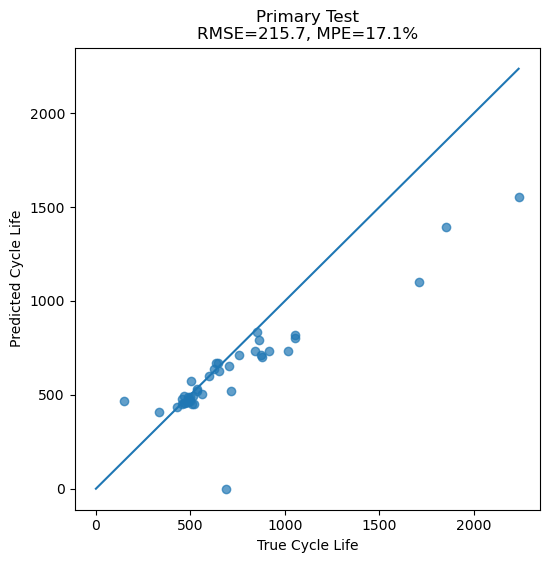

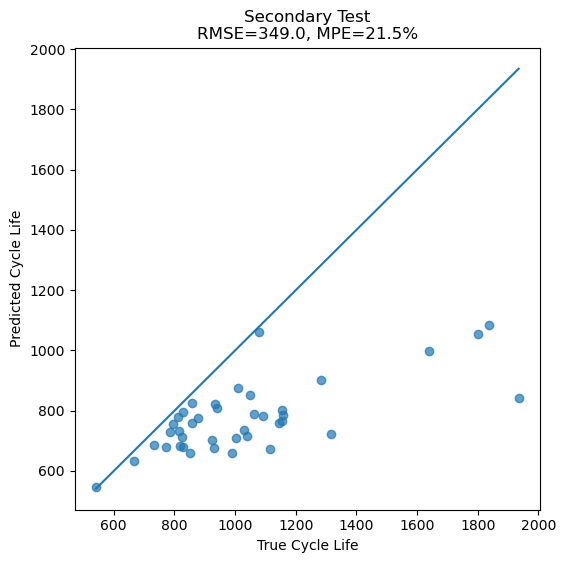

In [21]:
# Final results

best_model.eval()

# Train predictions

with torch.no_grad():

    train_pred_log = (
        best_model(X_train_tensor.to(device))
        .cpu()
        .numpy()
        .flatten()
    )

train_pred = 10 ** train_pred_log
train_true = 10 ** y_train

train_rmse = np.sqrt(mean_squared_error(train_true, train_pred))
train_mpe = np.mean(np.abs(train_pred - train_true) / train_true) * 100

# Primary test predictions

with torch.no_grad():

    primary_pred_log = (
        best_model(X_primary_tensor.to(device))
        .cpu()
        .numpy()
        .flatten()
    )

primary_pred = 10 ** primary_pred_log
primary_true = 10 ** y_primary_test

primary_rmse = np.sqrt(mean_squared_error(primary_true, primary_pred))
primary_mpe = np.mean(np.abs(primary_pred - primary_true) / primary_true) * 100

# Secondary test predictions

with torch.no_grad():

    secondary_pred_log = (
        best_model(X_secondary_tensor.to(device))
        .cpu()
        .numpy()
        .flatten()
    )

secondary_pred = 10 ** secondary_pred_log
secondary_true = 10 ** y_secondary_test

secondary_rmse = np.sqrt(mean_squared_error(secondary_true, secondary_pred))
secondary_mpe = np.mean(np.abs(secondary_pred - secondary_true) / secondary_true) * 100

# Summary table

summary_df = pd.DataFrame({
    "split": ["train", "primary_test", "secondary_test"],
    "rmse_cycles": [train_rmse, primary_rmse, secondary_rmse],
    "mean_percent_error": [train_mpe, primary_mpe, secondary_mpe]
})

display(summary_df)

# Primary test plot
plt.figure(figsize=(6, 6))
plt.scatter(
    primary_true,
    primary_pred,
    alpha=0.7
)

lims = [
    min(primary_true.min(), primary_pred.min()),
    max(primary_true.max(), primary_pred.max())
]

plt.plot(lims, lims)
plt.xlabel("True Cycle Life")
plt.ylabel("Predicted Cycle Life")
plt.title(f"Primary Test\nRMSE={primary_rmse:.1f}, MPE={primary_mpe:.1f}%")
plt.show()

# Secondary test plot
plt.figure(figsize=(6, 6))

plt.scatter(
    secondary_true,
    secondary_pred,
    alpha=0.7
)

lims = [
    min(secondary_true.min(), secondary_pred.min()),
    max(secondary_true.max(), secondary_pred.max())
]

plt.plot(lims, lims)

plt.xlabel("True Cycle Life")
plt.ylabel("Predicted Cycle Life")
plt.title(f"Secondary Test\nRMSE={secondary_rmse:.1f}, MPE={secondary_mpe:.1f}%")
plt.show()

In [13]:
# Get ground truth + prediction for every battery
def make_mlp_results(split_df, true_cycle_life, pred_cycle_life):
    n = len(true_cycle_life)

    return pd.DataFrame({
        "battery_id": split_df["battery_id"].values[:n],
        "true_cycle_life": true_cycle_life,
        "pred_cycle_life": pred_cycle_life,
        "abs_percent_error": (np.abs(pred_cycle_life - true_cycle_life) / true_cycle_life * 100)
    })


train_mlp_results = make_mlp_results(train_df, train_true, train_pred)
primary_mlp_results = make_mlp_results(primary_test_df, primary_true, primary_pred)
secondary_mlp_results = make_mlp_results(secondary_test_df, secondary_true, secondary_pred)

display(HTML("<h3>Train Set MLP Results</h3>"))
display(train_mlp_results)

display(HTML("<h3>Primary Test Set MLP Results</h3>"))
display(primary_mlp_results)

display(HTML("<h3>Secondary Test Set MLP Results</h3>"))
display(secondary_mlp_results)

,battery_id,true_cycle_life,pred_cycle_life,abs_percent_error
0,b1c1,2160.0,2118.345947,1.928428
1,b1c3,1434.0,1280.918579,10.675134
2,b1c5,1074.0,976.818359,9.048570
3,b1c7,870.0,840.568665,3.382912
4,b1c11,788.0,754.560608,4.243578
5,b1c15,719.0,676.709290,5.881879
6,b1c17,857.0,819.946411,4.323639
7,b1c19,788.0,770.717468,2.193215
8,b1c21,559.0,579.832520,3.726748
9,b1c24,1017.0,936.698975,7.895873


,battery_id,true_cycle_life,pred_cycle_life,abs_percent_error
0,b1c0,1852.0,1.434577e+03,22.539064
1,b1c2,2237.0,1.733141e+03,22.523866
2,b1c4,1709.0,1.311327e+03,23.269330
3,b1c6,636.0,7.575940e+02,19.118553
4,b1c9,1054.0,8.956822e+02,15.020665
5,b1c14,880.0,7.824180e+02,11.088867
6,b1c16,862.0,9.465475e+02,9.808293
7,b1c18,691.0,2.022856e-07,100.000000
8,b1c20,534.0,5.660662e+02,6.004911
9,b1c23,1014.0,8.971492e+02,11.523751


,battery_id,true_cycle_life,pred_cycle_life,abs_percent_error
0,b3c0,1009.0,909.578369,9.853482
1,b3c1,1063.0,808.119263,23.977492
2,b3c3,1115.0,699.189209,37.292448
3,b3c4,1048.0,875.014832,16.506218
4,b3c5,828.0,731.783691,11.620327
5,b3c6,667.0,557.495117,16.417524
6,b3c7,1836.0,1010.556213,44.958812
7,b3c8,828.0,852.936218,3.011621
8,b3c9,1039.0,850.257812,18.165754
9,b3c10,1078.0,970.196167,10.000356
